In [1]:
import torch
import numpy as np

# Tensor

## Initializing Values

In [14]:
# raw data declare
data = [[0,1,2], [3,4,5]]
t = torch.tensor(data)
print(f'{t}, \n{t.dtype}, \n{t.shape} --> {t.shape[0]}, {t.shape[1]}')
print(t.type)
print(t.device)

tensor([[0, 1, 2],
        [3, 4, 5]]), 
torch.int64, 
torch.Size([2, 3]) --> 2, 3
<built-in method type of Tensor object at 0x1158ad950>
cpu


In [10]:
# from numpy
data = np.array([[0,1,2], [3,4,5]])
t = torch.from_numpy(data)
print(f"{t}, \n{t.dtype}\n")

#changing in numpy
data[0,0] = 100
print(f"After changing data in numpy array, t is\n{t}")

#changing in tensor
t[0,0] = 101
print(f"After changing in tensor, numpy is\n{data}")

tensor([[0, 1, 2],
        [3, 4, 5]]), 
torch.int64

After changing data in numpy array, t is
tensor([[100,   1,   2],
        [  3,   4,   5]])
After changing in tensor, numpy is
[[101   1   2]
 [  3   4   5]]


In [12]:
# from another tensor
print(f"torch.ones_like {torch.ones_like(t)}")
print(f"torch.rand_like {torch.rand_like(t, dtype=torch.float64)}")
print(f"torch.zeros_like {torch.zeros_like(t)}")

torch.ones_like tensor([[1, 1, 1],
        [1, 1, 1]])
torch.rand_like tensor([[0.3321, 0.8856, 0.3407],
        [0.0691, 0.4713, 0.4198]], dtype=torch.float64)
torch.zeros_like tensor([[0, 0, 0],
        [0, 0, 0]])


In [13]:
shape = (2,3)
print(f"torch.rand {torch.rand(shape)}")
print(f"torch.zeros {torch.zeros(shape)}")
print(f"torch.ones {torch.ones(shape)}")

torch.rand tensor([[0.0339, 0.4892, 0.8518],
        [0.5894, 0.6619, 0.1159]])
torch.zeros tensor([[0., 0., 0.],
        [0., 0., 0.]])
torch.ones tensor([[1., 1., 1.],
        [1., 1., 1.]])


## Operations on Tensor

In [17]:
have_accelerator = torch.accelerator.is_available()
device = torch.accelerator.current_accelerator() if have_accelerator else "cpu"

print(have_accelerator, device)

True mps


### Indexing and concatenation

In [21]:
#slicing
data = torch.randint(low=0, high=20, size=(4,4))
print(f"data: {data}")

print(f"first row: {data[0]}")
print(f"first column: {data[:,0]}")
print(f"last column: {data[:,-1]}")

data: tensor([[ 0,  8, 15, 16],
        [19,  4,  2,  8],
        [ 3,  5, 11,  1],
        [ 0,  3,  0,  8]])
first row: tensor([ 0,  8, 15, 16])
first column: tensor([ 0, 19,  3,  0])
last column: tensor([16,  8,  1,  8])


![](https://miro.medium.com/v2/resize:fit:1200/0*pQ8eNElN4UG6an_A.png)

In [ ]:
# let's try 3d data
data = torch.randint(low=0, high=10, size=(2,3,4))
print(f"data: {data}")

print(f"first row: {data[0]}")
print(f"first column: {data[:,0]}")
print(f"data in depth layer of both rows and 2nd col: {data[:,1,2]}")


data: tensor([[[6, 3, 5, 6],
         [0, 6, 0, 9],
         [5, 1, 7, 1]],

        [[5, 0, 2, 1],
         [3, 8, 6, 2],
         [8, 3, 0, 3]]])
first row: tensor([[6, 3, 5, 6],
        [0, 6, 0, 9],
        [5, 1, 7, 1]])
first column: tensor([[6, 3, 5, 6],
        [5, 0, 2, 1]])
data in depth layer of both rows and 2nd col: tensor([0, 6])


In [35]:
# concatenate tensors along a given dim
t = torch.tensor([[2,2], [3,3]])
print(torch.cat([t,t,t], dim=0))
print(torch.cat([t,t,t], dim=1))

tensor([[2, 2],
        [3, 3],
        [2, 2],
        [3, 3],
        [2, 2],
        [3, 3]])
tensor([[2, 2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3, 3]])


### Arithmetic operations

In [47]:
print("Matrix Multiplication product")
t = torch.tensor([[1,1,1],[2,2,2]])

#matrix multiplication
print(t @ t.T)
print(t.matmul(t.T))

Matrix Multiplication product
tensor([[ 3,  6],
        [ 6, 12]])
tensor([[ 3,  6],
        [ 6, 12]])


In [48]:
print("Matrix Multiplication product")
matmul = torch.ones(size=(t.shape[0], t.shape[0]), dtype=torch.long)
torch.matmul(t, t.T, out=matmul)
print(matmul)

Matrix Multiplication product
tensor([[ 3,  6],
        [ 6, 12]])


In [49]:
## Element wise product
print("Elementwise product")
print(t * t)
print()

Elementwise product
tensor([[1, 1, 1],
        [4, 4, 4]])



In [52]:
print("Single Element Tensors")
sum = t.sum()
print(sum, sum.item(), type(sum), type(sum.item()))

Single Element Tensors
tensor(9) 9 <class 'torch.Tensor'> <class 'int'>


In [55]:
print("Inplace operations")
t.add(5)
print(t)

t.add_(5)
print(t)

Inplace operations
tensor([[1, 1, 1],
        [2, 2, 2]])
tensor([[6, 6, 6],
        [7, 7, 7]])


# Datasets and DataLoaders

## FashionMNIST Dataset

In [138]:
import torch
from torchvision.transforms import v2
from torch.utils.data import Dataset
from torchvision import datasets
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [147]:
train = datasets.FashionMNIST(
    root = "../../Datasets",
    train = True,
    download = True,
    
    # won't be applied during init, but only during the fetch
    transform = v2.Compose([ v2.ToImage(), v2.ToDtype(dtype=torch.float32, scale=True) ])
)

In [148]:
test = datasets.FashionMNIST(
    root = "../../Datasets",
    train = False,
    download = True,
    transform = v2.Compose([ v2.ToImage(), v2.ToDtype(dtype=torch.float32, scale=True) ])
)

In [149]:
train

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../../Datasets
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [150]:
print(f"Training data size: {train.data.shape} of dtype:{train.data.dtype}")
print(f"Testing data size: {test.data.shape}")
print(f"LabelVsIndex: {train.class_to_idx}")
print(f"Training labels: {train.targets}")

Training data size: torch.Size([60000, 28, 28]) of dtype:torch.uint8
Testing data size: torch.Size([10000, 28, 28])
LabelVsIndex: {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Training labels: tensor([9, 0, 0,  ..., 3, 0, 5])


In [151]:
classes = {idx:c for idx,c in enumerate(train.classes)}
classes

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

In [152]:
idx = torch.randint(low=0, high=train.data.shape[0], size=(1,))
sample_data = train.data[idx]
print(f"Shape of sample data: {sample_data.shape}")
sample_data = sample_data.squeeze()
print(f"Shape of squeezed sample data: {sample_data.shape}")
print(sample_data)

Shape of sample data: torch.Size([1, 28, 28])
Shape of squeezed sample data: torch.Size([28, 28])
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6, 121,  90,
           0,  48,   0,   0,   0,   0,   0,   0,   0,  26,   8,   0,   3,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   0, 175, 204, 245,
          51, 207, 206, 187, 174, 168, 167, 172, 172, 174,  88,   0,   4,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   3,   0,   7, 179, 195, 217,
          58, 139, 201, 192, 193, 192, 187, 181, 178, 182,  89,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   4,   0,  14, 193, 195, 233,
         100,  98, 219, 182, 184, 181, 176, 173, 170, 182, 107,   0,   1,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   3,   0,   0, 178, 200, 230,
         170,  55, 223, 183,

### Visualizing the images

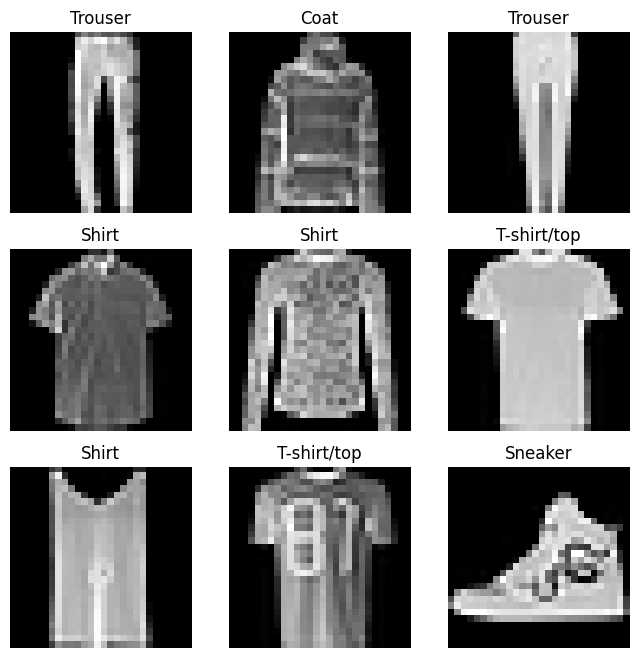

In [153]:
#plotting the data
figure = plt.figure(figsize=(8,8))
rows, cols = 3,3
for i in range(9):
    idx = torch.randint(low=0, high=train.data.shape[0], size=(1,))
    d = train.data[idx]
    l = train.targets[idx]

    figure.add_subplot(rows, cols, i+1)
    plt.title(label=classes[l.item()])
    plt.axis("off")
    plt.imshow(d.squeeze(), cmap='gray')
    
plt.show()

## CustomDataSet

In [154]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def __len__(self):
        return self.x.shape[0]
    
    def __getitem__(self, idx):
        if not (idx >= 0 and idx < self.__len__()):
            raise Exception("idx out of range")
        d, l = self.x[idx], self.y[idx]
        return d, l
    
    def __repr__(self):
        return f"X of shape {self.x.shape} and Y of shape {self.y.shape}\nDType: {type(self.x)}"

In [155]:
n = 50
tempd = train.data[:50]
templ = train.targets[:50]

dset = CustomDataset(tempd, templ)
dset


X of shape torch.Size([50, 28, 28]) and Y of shape torch.Size([50])
DType: <class 'torch.Tensor'>

## Preparing your data for training with DataLoaders

In [156]:
from torch.utils.data import DataLoader

In [157]:
train_loader = DataLoader(dataset=train, batch_size=64, shuffle=True)
train_loader

In [158]:
next(iter(train_loader))

[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

torch.Size([64, 1, 28, 28]) torch.Size([64]) <class 'torch.Tensor'>


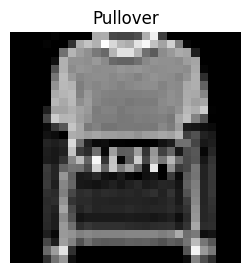

In [159]:
tx, ty = next(iter(train_loader))
print(tx.shape, ty.shape, type(tx))

idx = 0
plt.figure(figsize=(3,3))
plt.imshow(tx[idx].squeeze(), cmap='gray')
plt.axis("off")
plt.title(classes[ty[idx].item()])
plt.show()

# Transforms

In [186]:
train = datasets.FashionMNIST(
    root = "../../Datasets",
    train = True,
    download = True,
    
    # won't be applied during init, but only during the fetch
    transform = v2.Compose([ v2.ToImage(), v2.ToDtype(dtype=torch.float32, scale=True) ]),
    
    # target transform
    target_transform=v2.Lambda(
        lambda y: F.one_hot(torch.tensor(y, dtype=torch.long), num_classes=10).float()
    )
)

In [187]:
train.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [188]:
train.targets[0]

tensor(9)

In [189]:
F.one_hot(train.targets[0], num_classes=10).float()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [190]:
train_loader = DataLoader(train, batch_size=32, shuffle=True)
tx, ty = next(iter(train_loader))

In [201]:
print("1st data's target")
print(f"with one-hot encoding: {ty[0]}")

1st data's target
with one-hot encoding: tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])


# Build the neural network

In [202]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os

## Setting the NeuralNetwork Architecture

### nn.Linear

In [232]:
x = torch.randint(low=0,high=20,size=(2,), dtype=torch.float32)
print(f"Input: {x}")
print("-------")
m = nn.Linear(in_features=2, out_features=1)
print(f"m.weight of shape {m.weight.shape}\n{m.weight}")
print(f"bias: {m.bias}")
print("-------")
print(f"linear activation wx+b: {m(x)}")

Input: tensor([6., 8.])
-------
m.weight of shape torch.Size([1, 2])
Parameter containing:
tensor([[0.3391, 0.5973]], requires_grad=True)
bias: Parameter containing:
tensor([0.1194], requires_grad=True)
-------
linear activation wx+b: tensor([6.9328], grad_fn=<ViewBackward0>)


### nn.Flatten

In [254]:
d1 = torch.tensor([[1,2],[3,4]])
print(d1)
print(f"Before flattening: {d1.shape}")
flat = nn.Flatten(start_dim=0)
d2 = flat(d1)
print(f"After flattening: {d2.shape}")

d3 = d1.unsqueeze(dim=0)
flat2 = nn.Flatten()
print(f"After unsqueezing: {d3.shape}\n{d3}")
print(f"Then flatten it : {flat2(d3).shape} -> {flat2(d3)}")

tensor([[1, 2],
        [3, 4]])
Before flattening: torch.Size([2, 2])
After flattening: torch.Size([4])
After unsqueezing: torch.Size([1, 2, 2])
tensor([[[1, 2],
         [3, 4]]])
Then flatten it : torch.Size([1, 4]) -> tensor([[1, 2, 3, 4]])


### nn.Relu

In [281]:
relu = nn.ReLU()
x = torch.rand(size=(2,))
print(x)
linear = nn.Linear(2,1)
print(f"linear parameters: {linear.weight.data} and bias {linear.bias.data}")
lx = linear(x)
print(f"Applying Linear: {lx}")
rx = relu(lx)
print(f"Applying Relu: {rx}")

tensor([0.5968, 0.9478])
linear parameters: tensor([[ 0.0530, -0.1112]]) and bias tensor([0.6301])
Applying Linear: tensor([0.5563], grad_fn=<ViewBackward0>)
Applying Relu: tensor([0.5563], grad_fn=<ReluBackward0>)


### nn.Sequential

In [297]:
x = torch.tensor([[2,3]], dtype=torch.float32)
flatten = nn.Flatten(start_dim=0)
linear = nn.Linear(2,1)
relu = nn.ReLU()

sequential = nn.Sequential(
    flatten,
    linear,
    relu
)

print(f"input shape: {x.shape}")
print(f"Individual output:")
print(f"flatten: {flatten(x)} and shape now is {flatten(x).shape}")
print(f"linear params: {linear.weight.data}, {linear.bias.data}")
print(f"linear: {linear(flatten(x))}")
print(f"relu: {relu(linear(flatten(x)))}")
print(f"-----\nSequential output")
print(f"Sequential: {sequential(x)}")

input shape: torch.Size([1, 2])
Individual output:
flatten: tensor([2., 3.]) and shape now is torch.Size([2])
linear params: tensor([[-0.3467,  0.5779]]), tensor([0.2687])
linear: tensor([1.3092], grad_fn=<ViewBackward0>)
relu: tensor([1.3092], grad_fn=<ReluBackward0>)
-----
Sequential output
Sequential: tensor([1.3092], grad_fn=<ReluBackward0>)


### nn.Softmax

In [303]:
logits = torch.tensor([1,2,3], dtype=torch.float32)
smax = nn.Softmax(dim=0)
print(smax(logits))

tensor([0.0900, 0.2447, 0.6652])


### Neural Network

In [312]:
class NeuralNetwork(nn.Module):
    
    def __init__(self, image_size):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Flatten(), #because image is going to [channel,height,width] flatenned to [channel,height*width]
            nn.Linear(image_size, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
        
    def forward(self, x):
        logits = self.layers(x)
        return logits

In [313]:
network = NeuralNetwork(image_size=28*28)
network

NeuralNetwork(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [322]:
test_data = torch.rand(3,28,28)
logits = network(test_data)
print(f"logits shape: {logits.shape}\n{logits}")

logits shape: torch.Size([3, 10])
tensor([[ 0.0359,  0.1026,  0.1502, -0.0349,  0.0200, -0.0160,  0.0643,  0.0430,
         -0.0013,  0.0072],
        [-0.0005,  0.0582,  0.0955, -0.0500, -0.0308, -0.0118,  0.0196,  0.0019,
         -0.0182, -0.0098],
        [ 0.0239,  0.1306,  0.1454, -0.0499, -0.0006, -0.0187,  0.0790, -0.0331,
          0.0074,  0.0280]], grad_fn=<AddmmBackward0>)


In [325]:
for name, param in network.named_parameters():
    print(name, param.size())

layers.1.weight torch.Size([512, 784])
layers.1.bias torch.Size([512])
layers.3.weight torch.Size([512, 512])
layers.3.bias torch.Size([512])
layers.5.weight torch.Size([10, 512])
layers.5.bias torch.Size([10])


# Automatic Differentiation with torch.autograd

## loss.backward()

In [349]:
x = torch.ones(5) #input
y = torch.tensor([1,0,1], dtype=torch.float32) #output

w = torch.randn(size=(5,3), requires_grad=True)
b = torch.randn(size=(3,), requires_grad=True)

wx = (x@w)
logit = wx + b
print(logit)

tensor([0.6951, 3.3448, 0.3207], grad_fn=<AddBackward0>)


In [351]:
print(y)

tensor([1., 0., 1.])


In [352]:
loss = F.binary_cross_entropy_with_logits(logit, y)
loss

tensor(1.4433, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [353]:
loss.backward()

In [354]:
print(f"w.grad: {w.grad}, b.grad: {b.grad}")

w.grad: tensor([[-0.1110,  0.3220, -0.1402],
        [-0.1110,  0.3220, -0.1402],
        [-0.1110,  0.3220, -0.1402],
        [-0.1110,  0.3220, -0.1402],
        [-0.1110,  0.3220, -0.1402]]), b.grad: tensor([-0.1110,  0.3220, -0.1402])


## torch.no_grad() 

In [355]:
x = torch.ones(5) #input
y = torch.tensor([1,0,1], dtype=torch.float32) #output

w = torch.randn(size=(5,3), requires_grad=True)
b = torch.randn(size=(3,), requires_grad=True)

wxb = x@w + b
print(wxb.requires_grad)

True


In [357]:
with torch.no_grad():
    wxb1 = x@w + b
print(wxb1.requires_grad)

False


In [361]:
x = torch.ones(5) #input
y = torch.tensor([], dtype=torch.float32) #output

w1 = torch.randn(size=(5,3), requires_grad=True)
b1 = torch.randn(size=(3,), requires_grad=True)

w2 = torch.randn(size=(3,1), requires_grad=True)
b2 = torch.randn(size=(1,), requires_grad=True)

wxb1 = (x@w1 + b1)
a1 = nn.Tanh()(wxb1)

wxb2 = (a1@w2 + b2)
a2 = nn.Tanh()(wxb2)

print(wxb1.requires_grad)
print(wxb2.requires_grad)
print(w.requires_grad)
print(b.requires_grad)

True
True
True
True


In [ ]:
wxb1.detach_() #inplace

tensor([ 2.5514, -0.8094, -2.9145])

In [ ]:
print(wxb1.requires_grad)
print(wxb2.requires_grad)
print(w.requires_grad) #previous layers' requires_grad are not setting to false
print(b.requires_grad) #previous layers' requires_grad are not setting to false

False
True
True
True


## grad.zero_()

In [386]:
class tmpnetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(start_dim=1),
            #input is 5dim
            nn.Linear(5,3),
            nn.Tanh(),
            nn.Linear(3,1),
            nn.Tanh()
        )
        
    def forward(self, x):
        logits = self.layers(x)
        return logits

In [389]:
x = torch.randn(5).unsqueeze(dim=0) #input
y = torch.ones(1)
nx = tmpnetwork()
y_pred = nx(x)

In [390]:
print(x.shape, y.shape)

torch.Size([1, 5]) torch.Size([1])


In [400]:
loss = [(yp-ya)**2 for yp,ya in zip(y_pred, y)][0]

In [401]:
for name, p in nx.named_parameters():
    print(name, p, p.grad)

layers.1.weight Parameter containing:
tensor([[ 0.1510,  0.2234,  0.1579,  0.0242,  0.2429],
        [ 0.0282,  0.4374,  0.1484,  0.3095, -0.4409],
        [ 0.3923,  0.4436, -0.3273,  0.2430, -0.1805]], requires_grad=True) None
layers.1.bias Parameter containing:
tensor([-0.1838,  0.2911,  0.3337], requires_grad=True) None
layers.3.weight Parameter containing:
tensor([[ 0.3761,  0.4464, -0.0472]], requires_grad=True) None
layers.3.bias Parameter containing:
tensor([-0.3833], requires_grad=True) None


In [402]:
loss.backward()

In [403]:
for name, p in nx.named_parameters():
    print(name, p, p.grad)

layers.1.weight Parameter containing:
tensor([[ 0.1510,  0.2234,  0.1579,  0.0242,  0.2429],
        [ 0.0282,  0.4374,  0.1484,  0.3095, -0.4409],
        [ 0.3923,  0.4436, -0.3273,  0.2430, -0.1805]], requires_grad=True) tensor([[-1.1888, -0.5538,  1.0351,  0.6535, -0.2121],
        [-1.3986, -0.6515,  1.2177,  0.7689, -0.2495],
        [ 0.0389,  0.0181, -0.0339, -0.0214,  0.0069]])
layers.1.bias Parameter containing:
tensor([-0.1838,  0.2911,  0.3337], requires_grad=True) tensor([-0.8903, -1.0473,  0.0292])
layers.3.weight Parameter containing:
tensor([[ 0.3761,  0.4464, -0.0472]], requires_grad=True) tensor([[-0.0315, -0.2266, -2.0357]])
layers.3.bias Parameter containing:
tensor([-0.3833], requires_grad=True) tensor([-2.3676])


In [ ]:
#consider it as second data input without setting zero grad
y_pred = nx(x)
loss = [(yp-ya)**2 for yp,ya in zip(y_pred, y)][0]
loss.backward()

In [406]:
for name, p in nx.named_parameters():
    print(name, p, p.grad)

layers.1.weight Parameter containing:
tensor([[ 0.1510,  0.2234,  0.1579,  0.0242,  0.2429],
        [ 0.0282,  0.4374,  0.1484,  0.3095, -0.4409],
        [ 0.3923,  0.4436, -0.3273,  0.2430, -0.1805]], requires_grad=True) tensor([[-2.3777, -1.1075,  2.0701,  1.3071, -0.4242],
        [-2.7972, -1.3029,  2.4354,  1.5377, -0.4990],
        [ 0.0779,  0.0363, -0.0678, -0.0428,  0.0139]])
layers.1.bias Parameter containing:
tensor([-0.1838,  0.2911,  0.3337], requires_grad=True) tensor([-1.7805, -2.0947,  0.0583])
layers.3.weight Parameter containing:
tensor([[ 0.3761,  0.4464, -0.0472]], requires_grad=True) tensor([[-0.0629, -0.4532, -4.0714]])
layers.3.bias Parameter containing:
tensor([-0.3833], requires_grad=True) tensor([-4.7352])


In [407]:
nx.zero_grad()
y_pred = nx(x)
loss = [(yp-ya)**2 for yp,ya in zip(y_pred, y)][0]
loss.backward()

In [408]:
for name, p in nx.named_parameters():
    print(name, p, p.grad)

layers.1.weight Parameter containing:
tensor([[ 0.1510,  0.2234,  0.1579,  0.0242,  0.2429],
        [ 0.0282,  0.4374,  0.1484,  0.3095, -0.4409],
        [ 0.3923,  0.4436, -0.3273,  0.2430, -0.1805]], requires_grad=True) tensor([[-1.1888, -0.5538,  1.0351,  0.6535, -0.2121],
        [-1.3986, -0.6515,  1.2177,  0.7689, -0.2495],
        [ 0.0389,  0.0181, -0.0339, -0.0214,  0.0069]])
layers.1.bias Parameter containing:
tensor([-0.1838,  0.2911,  0.3337], requires_grad=True) tensor([-0.8903, -1.0473,  0.0292])
layers.3.weight Parameter containing:
tensor([[ 0.3761,  0.4464, -0.0472]], requires_grad=True) tensor([[-0.0315, -0.2266, -2.0357]])
layers.3.bias Parameter containing:
tensor([-0.3833], requires_grad=True) tensor([-2.3676])


# Optimizing Model Parameters

## Known setup

In [409]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision import datasets
from torch.utils.data import DataLoader

In [416]:
train = datasets.FashionMNIST(
    root = "../../Datasets",
    train = True,
    transform = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(dtype=torch.float32, scale=True)
        ])
    # not doing the below for the nn.CrossEntropyLoss() which expects the output numbers
    # target_transform = lambda y: F.one_hot(y, num_classes=10)
)
test = datasets.FashionMNIST(
    root = "../../Datasets",
    train = False,
    transform = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(dtype=torch.float32, scale=True)
        ])
)

In [417]:
class model(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
        
    def forward(self, X):
        logits = self.layers(X)
        return logits

In [421]:
m = model()

In [422]:
m.parameters()

<generator object Module.parameters at 0x1230c7970>

## Hyperparameters and training loop

In [419]:
epoch = 5
batch_size = 64
learning_rate = 1e-3

## Loss Functions and Optimizers

In [423]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = m.parameters(), lr=learning_rate)

## Training Loop

In [476]:
def training_loop(m, train, batch_size, optimizer, debug=False):
    train_loader = DataLoader(train, batch_size=batch_size)
    m.train()
    last_loss = 0.0
    for batch, (X,y) in enumerate(train_loader):
        # forward pass
        pred = m(X)
        
        # loss function
        epoch_loss = loss_fn(pred, y)
        last_loss = epoch_loss.item()
        
        # backprop
        epoch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        if batch%100 == 0 and debug:
            print(f"Loss: {epoch_loss.item()},[{batch*batch_size}/{len(train_loader.dataset)}]")
    print(f"Last loss in this epoch: {last_loss}")

m = model()
optimizer = torch.optim.SGD(params = m.parameters(), lr=learning_rate)
training_loop(m, train, batch_size, optimizer, debug=True)

Loss: 2.303863525390625,[0/60000]
Loss: 2.2959086894989014,[6400/60000]
Loss: 2.273073434829712,[12800/60000]
Loss: 2.2691338062286377,[19200/60000]
Loss: 2.2559404373168945,[25600/60000]
Loss: 2.2223029136657715,[32000/60000]
Loss: 2.2341129779815674,[38400/60000]
Loss: 2.196249485015869,[44800/60000]
Loss: 2.1971182823181152,[51200/60000]
Loss: 2.1665055751800537,[57600/60000]
Last loss in this epoch: 2.1475014686584473


In [ ]:
test_data = test[0]
testx = test_data[0]
testy = test_data[1]
with torch.no_grad():
    pred = m(test_data[0])
    ypred = pred.argmax()
    print(pred, ypred.float().item())

tensor([[-0.0352, -0.0876, -0.0419, -0.0909,  0.0109, -0.0204, -0.0652,  0.0476,
          0.0855,  0.1729]]) 9.0 tensor([[False, False, False, False, False, False, False, False, False, False]])


In [470]:
def test_loop(m, test_data, batch_size):
    test_loader = DataLoader(test_data, batch_size=batch_size)
    size = len(test_loader.dataset)
    m.eval()
    loss, correct_count = 0, 0
    
    with torch.no_grad():
        for batch, (X,y) in enumerate(test_loader):
            # forward pass
            pred = m(X)
            #print(pred.shape)
            
            # loss function
            loss += loss_fn(pred, y)
            correct = (pred.argmax(1) == y).float()
            #print(correct.sum().item())
            correct_count += correct.sum().item()
            
    print(f"Accuracy: {100*correct_count/size}%")
            

test_loop(m, test, batch_size)

Accuracy: 36.25%


In [477]:

m = model()
optimizer = torch.optim.SGD(params = m.parameters(), lr=learning_rate)

for i in range(epoch):
    print(f"Epoch: {i+1}")
    training_loop(m, train, batch_size, optimizer)    
    test_loop(m, test, batch_size)

Epoch: 1
Last loss in this epoch: 2.1585123538970947
Accuracy: 43.78%
Epoch: 2
Last loss in this epoch: 1.9014798402786255
Accuracy: 57.93%
Epoch: 3
Last loss in this epoch: 1.5627070665359497
Accuracy: 62.23%
Epoch: 4
Last loss in this epoch: 1.307539463043213
Accuracy: 63.68%
Epoch: 5
Last loss in this epoch: 1.1573036909103394
Accuracy: 64.87%


# Save and Load the Model

## Deprecated way

In [491]:
torch.save(m, "fashionmnist.pth")

In [492]:
nm = torch.load("fashionmnist.pth", weights_only=False)
nm

model(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [493]:
test_data = test[0]
testx = test_data[0]
testy = test_data[1]
with torch.no_grad():
    pred = nm(test_data[0])
    ypred = pred.argmax()
    print(pred, ypred.float().item())

tensor([[-2.4618, -2.8664, -0.7683, -2.0999, -0.8699,  2.3195, -1.0118,  2.5178,
          1.7558,  3.0476]]) 9.0


## Recommended way

In [494]:
torch.save(m.state_dict(), "fashionmnist_dict.pth") #this can't be called directly as model

In [495]:
nm = model()
state_dict = torch.load("fashionmnist_dict.pth", map_location="cpu")
nm.load_state_dict(state_dict)
test_data = test[0]
testx = test_data[0]
testy = test_data[1]
with torch.no_grad():
    pred = nm(test_data[0])
    ypred = pred.argmax()
    print(pred, ypred.float().item())

tensor([[-2.4618, -2.8664, -0.7683, -2.0999, -0.8699,  2.3195, -1.0118,  2.5178,
          1.7558,  3.0476]]) 9.0
